# Exploratory Data Analysis (EDA) and Preprocessing

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from scipy.stats import skew
from pathlib import Path

# import config.py
sys.path.append(str(Path().resolve().parents[0]))
from config import *

In [2]:
# dataset loading
df = pd.read_csv(RAW_DIR / "UNSW_NB15_training-set.csv")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 1. Dataset Overview

In [3]:
print(f"Shape of the dataset: {df.shape}")
print(f"Number of unique labels: {df['label'].nunique()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Shape of the dataset: (175341, 45)
Number of unique labels: 2

Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
features = df.columns[:-1]  # Exclude the 'label' column
print(f"Feature columns: {features}")

Text(0.5, 1.0, 'Correlation Heatmap')

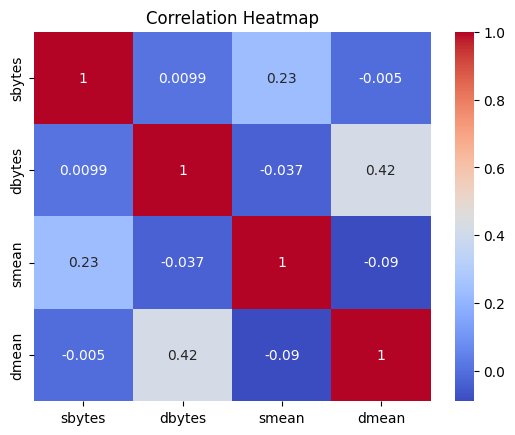

In [5]:
# Correlation heatmap
sns.heatmap(df[['sbytes','dbytes','smean','dmean']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

## 2. Feature Selection

### Volume-Based Features
- dur: Record total duration
- sbytes: Bytes sent from source
- dbytes: Bytes sent from destination
- rate: rate of traffic (intensity)

These represent traffic magnitude and may cause volume-based anomalies.

### Behavior-Based Features
- proto: Transaction protocol type (TCP, UDP, igmp, icmp,...)
- service: Application service (http, ftp, smtp,...)
- state: Connection state
- sttl / dttl: Time to Live value
- sinpkt / dinpkt: Inter-packet arrival time
- smean / dmean: Mean of packet size tranmitted

These represent how traffic behaves rather than how much traffic exists.

In [6]:
# Selecting features
selected_features = ['dur','sbytes','dbytes','rate','sttl','dttl','sinpkt','dinpkt','smean','dmean','proto','service','state','label']

df_processed = df[selected_features]
df_processed.head()

,dur,sbytes,dbytes,rate,sttl,dttl,sinpkt,dinpkt,smean,dmean,proto,service,state,label
0,0.121478,258,172,74.087490,252,254,24.295600,8.375000,43,43,tcp,-,FIN,0
1,0.649902,734,42014,78.473372,62,252,49.915000,15.432865,52,1106,tcp,-,FIN,0
2,1.623129,364,13186,14.170161,62,252,231.875571,102.737203,46,824,tcp,-,FIN,0
3,1.681642,628,770,13.677108,62,252,152.876547,90.235726,52,64,tcp,ftp,FIN,0
4,0.449454,534,268,33.373826,254,252,47.750333,75.659602,53,45,tcp,-,FIN,0


In [ ]:
df_processed.describe()

In [8]:
# Ploting function for distributions
def plot_distributions(df,f1,f2):
    plt.figure(figsize=(10, 3))

    subplt = plt.subplot(1, 2, 1)
    subplt.hist(df[f1], bins=50)
    subplt.set_title(f'Distribution of {f1}')

    subplt = plt.subplot(1, 2, 2)
    subplt.hist(df[f2], bins=50)
    subplt.set_title(f'Distribution of {f2}')

    plt.show()

## 3. log transformation to skewed data

In [ ]:
# Ckecking skewness
continuous_cols = ['dur','sbytes','dbytes','rate','sttl',
                   'dttl','sinpkt','dinpkt','smean','dmean']

for col in continuous_cols:
    print(f"{col}: skew = {skew(df_processed[col]):.2f}")

In [10]:
# Using log transformation to handle skewness
for col in ['dur','sbytes','dbytes','rate','smean','dmean','sinpkt','dinpkt']:
    df_processed[col] = np.log1p(df_processed[col])

In [11]:
# dur and smean required double log1p due to extreme initial skewness
for col in ['dur','smean']:
    df_processed[col] = np.log1p(df_processed[col])

In [12]:
for col in continuous_cols:
    print(f"{col}: skew = {skew(df_processed[col]):.2f}")

dur: skew = 1.85
sbytes: skew = 1.17
dbytes: skew = 0.37
rate: skew = -0.20
sttl: skew = -0.68
dttl: skew = 0.90
sinpkt: skew = 1.24
dinpkt: skew = 0.90
smean: skew = 1.74
dmean: skew = 0.22


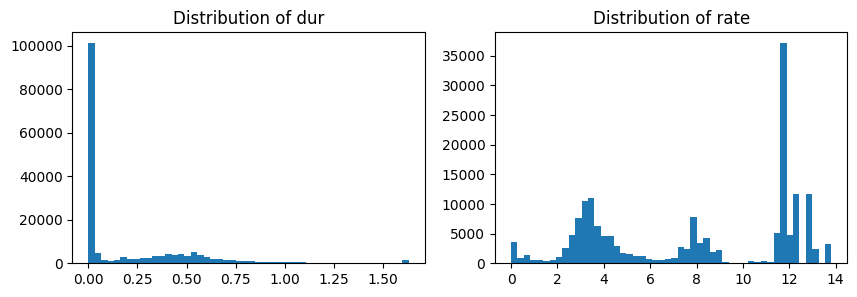

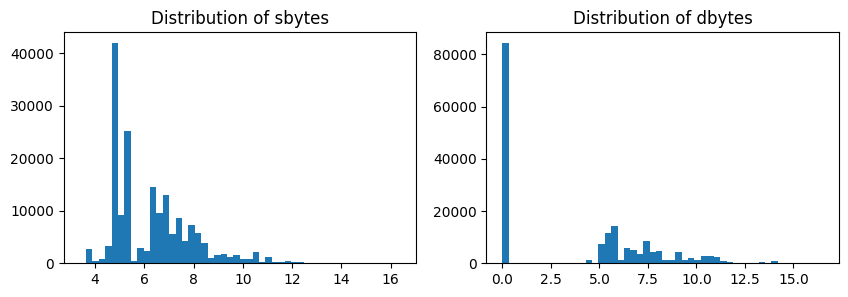

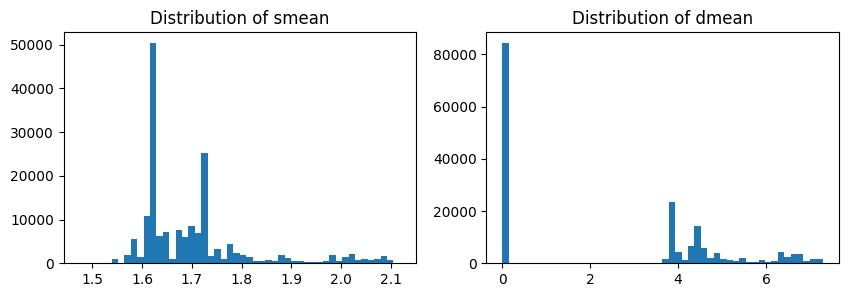

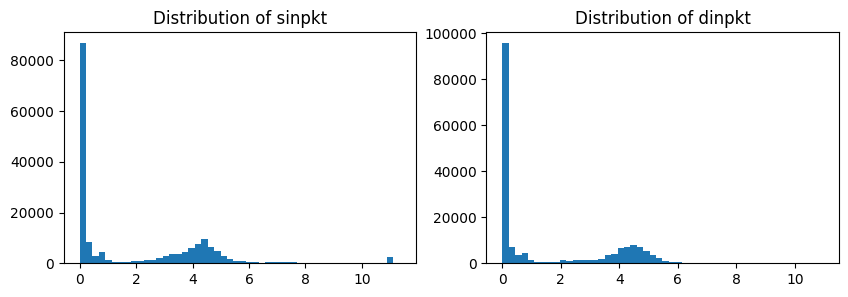

In [13]:
# Plotting distributions of lof-transformed features
plot_distributions(df_processed, 'dur', 'rate')
plot_distributions(df_processed, 'sbytes', 'dbytes')
plot_distributions(df_processed, 'smean', 'dmean')
plot_distributions(df_processed, 'sinpkt', 'dinpkt')

Text(0, 0.5, 'Attack rate (500-row window)')

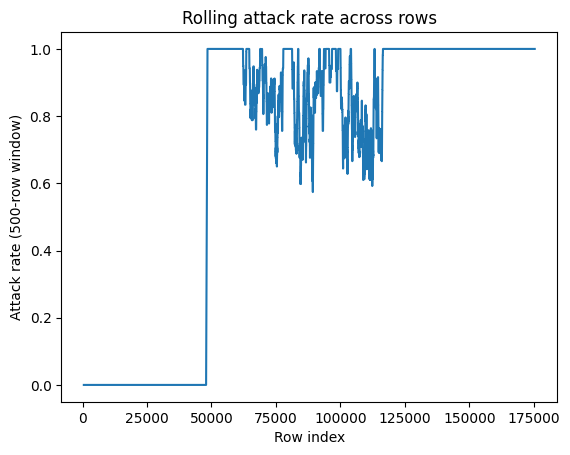

In [14]:
# Attack rate distribution on rolling window
plt.plot(df['label'].rolling(500).mean())
plt.title('Rolling attack rate across rows')
plt.xlabel('Row index')
plt.ylabel('Attack rate (500-row window)')

## 4. Categorical encoding

In [15]:
# categorical feature analysis
print(f"Number of unique protocols: {df_processed['proto'].nunique()}")
print(f"Number of unique services:  {df_processed['service'].nunique()}")
print(f"Number of unique states:    {df_processed['state'].nunique()}")

Number of unique protocols: 133
Number of unique services:  13
Number of unique states:    9


In [16]:
# one hot encoding for 'service' and 'state'
# 'proto' 133 unique values, it will shoot up the dimensions
df_ohe = df_processed.copy()
df_ohe = pd.get_dummies(df_ohe, columns=['service', 'state'], drop_first=False)

print(f"Shape of the processed dataset: {df_ohe.shape}")

Shape of the processed dataset: (175341, 34)


In [17]:
# Saving ohe columns for aligning test data
ohe_cols = [col for col in df_ohe.columns if col != 'label']
with open(PROCESSED_DIR / 'ohe_columns.json', 'w') as f:
    json.dump(ohe_cols, f)

print(f"OHE columns saved: {len(ohe_cols)}")

OHE columns saved: 33


## 5. Window-based aggregation
#### Since, no timestamps are given, we will aggrgate the row
#### Aggregate window_size flow (rows) into a single window
- Reduces noise
- Smooths natural fluctuations
- Highlights behavioral shifts

In [18]:
# Aggregation dictionary for windowing
agg_dict = {}

# Continues features
for col in continuous_cols:
    agg_dict[col] = ['mean','std']

# One-hot features
one_hot_cols = [col for col in df_ohe.columns if col.startswith('service') or col.startswith('state')]

for col in one_hot_cols:
    agg_dict[col] = 'mean'

# Protocol diversity
agg_dict['proto'] = 'nunique'

# Label aggregation
agg_dict['label'] = 'max'

In [19]:
# Creating windows and applying aggregation
df_ohe['window_id'] = df_ohe.index // WINDOW_SIZE

df_windowed = df_ohe.groupby('window_id').agg(agg_dict)
df_windowed.columns = ['_'.join(col).strip() for col in df_windowed.columns]

df_windowed = df_windowed.rename(columns={'label_max': 'window_attack'})
df_windowed = df_windowed.reset_index()

# dropping extremely sparse features.
df_windowed.drop(columns=['state_PAR_mean', 'state_URN_mean', 'state_no_mean'], inplace=True)

## 6. Windowed data analysis

In [ ]:
display(df_windowed.head())
print(f"Shape of windowed data: {df_windowed.shape}")

In [21]:
# Null value check
print(f"Null values: {df_windowed.isnull().sum().sum()}")

# Data balance check
df_windowed['window_attack'].value_counts()

Null values: 0


window_attack
1    1275
0     479
Name: count, dtype: int64

Text(0, 0.5, 'Attack rate (200-row window)')

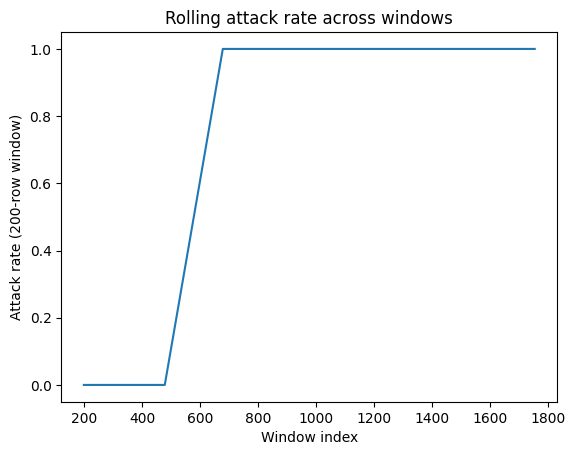

In [22]:
# Windowed attack rate
plt.plot(df_windowed['window_attack'].rolling(200).mean())
plt.title('Rolling attack rate across windows')
plt.xlabel('Window index')
plt.ylabel('Attack rate (200-row window)')

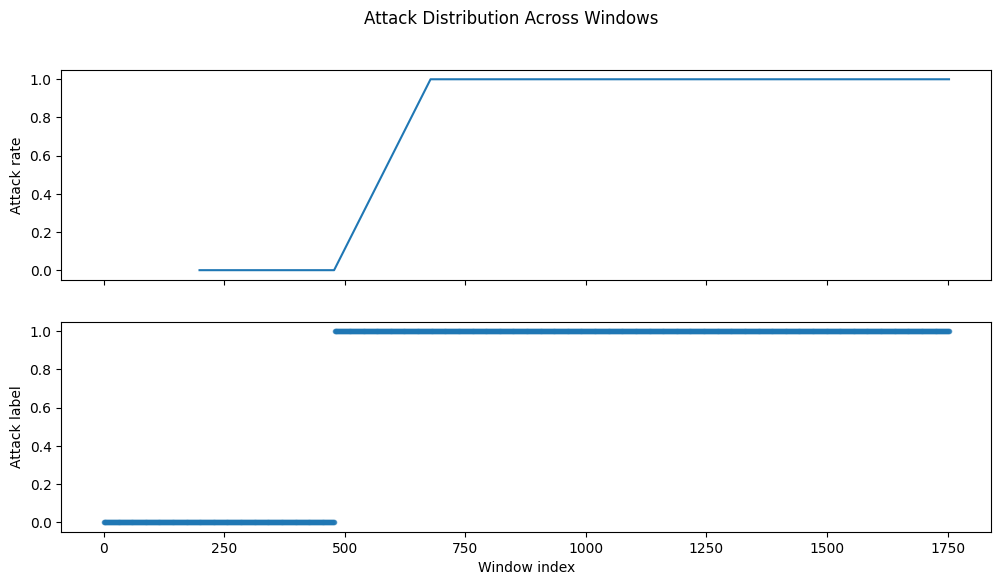

In [23]:
fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)

# rolling attack rate
ax[0].plot(df_windowed['window_attack'].rolling(200).mean())
ax[0].set_ylabel("Attack rate")

# raw attack labels
ax[1].plot(df_windowed['window_attack'], '.', alpha=0.4)
ax[1].set_xlabel("Window index")
ax[1].set_ylabel("Attack label")

plt.suptitle("Attack Distribution Across Windows")

plt.show()

In [24]:
# Saving windowed columns for aligning test data
expected_windowed_cols = list(df_windowed.columns)
with open(PROCESSED_DIR / 'windowed_columns.json', 'w') as f:
    json.dump(expected_windowed_cols, f)

print(f"Windowed columns saved: {len(expected_windowed_cols)}")

Windowed columns saved: 42


## 7. Normal data

In [25]:
# Use only normal windows for training
normal_windows = df_windowed[df_windowed['window_attack'] == 0]

print(normal_windows.shape)
normal_windows.head()

(479, 42)


,window_id,dur_mean,dur_std,sbytes_mean,sbytes_std,dbytes_mean,dbytes_std,rate_mean,rate_std,sttl_mean,...,service_ssh_mean,service_ssl_mean,state_CON_mean,state_ECO_mean,state_FIN_mean,state_INT_mean,state_REQ_mean,state_RST_mean,proto_nunique,window_attack
0,0,0.317844,0.383468,6.571681,1.138847,4.251369,3.409974,5.920870,4.008042,189.21,...,0.00,0.0,0.04,0.00,0.60,0.36,0.0,0.0,4,0
1,1,0.272340,0.536134,7.009990,0.916484,3.428353,4.077962,8.423115,3.942508,162.58,...,0.00,0.0,0.08,0.01,0.36,0.55,0.0,0.0,4,0
2,2,0.270119,0.511045,6.097047,1.266632,6.447499,1.852294,6.474863,2.489866,31.00,...,0.01,0.0,0.69,0.00,0.31,0.00,0.0,0.0,2,0
3,3,0.363759,0.534592,6.504552,1.270745,6.984390,1.912316,5.836960,2.809455,31.00,...,0.00,0.0,0.42,0.00,0.58,0.00,0.0,0.0,2,0
4,4,0.664023,0.625825,7.218754,0.761826,7.610472,1.454399,4.008287,2.882684,31.00,...,0.01,0.0,0.07,0.00,0.93,0.00,0.0,0.0,2,0


In [26]:
# Saving processed data
df_windowed.to_csv(PROCESSED_DIR / "full_windowed.csv", index=False)
normal_windows.to_csv(PROCESSED_DIR / "normal_windowed.csv", index=False)

## 8. Summary

In [27]:
print("\n===== Data Pre-processing Summary =====\n")

print(f"Window size:                    100 rows")
print(f"Total features:                 {len(df_windowed.columns[1:-1])}") # (excl. id and label)
print(f"Normal windows for training:    {len(normal_windows)}")
print(f"Total windows for evaluation:   {len(df_windowed)}")
print(f"Attack rate in full set:        {df_windowed['window_attack'].mean():.2%}")


===== Data Pre-processing Summary =====

Window size:                    100 rows
Total features:                 40
Normal windows for training:    479
Total windows for evaluation:   1754
Attack rate in full set:        72.69%
